In [1]:
# ============================================================
# TASK 1: Date Feature Engineering
# Dataset: q3_retail_promotions-1.csv
# Target : items_sold
# ============================================================

# Step 1: Import libraries
import pandas as pd

# Step 2: Load the dataset
df = pd.read_csv('q3_retail_promotions.csv')

print("Dataset Shape:", df.shape)
print("First 3 rows (original):")
print(df.head(3))

# ─────────────────────────────────────────────────────────────
# Step 3: Convert 'transaction_date' column to datetime format
# This is REQUIRED before we can extract date parts
# ─────────────────────────────────────────────────────────────
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# ─────────────────────────────────────────────────────────────
# Step 4: Extract date features from 'transaction_date'
# ─────────────────────────────────────────────────────────────

# 4a. Year (e.g., 2022, 2023, 2024)
df['year'] = df['transaction_date'].dt.year

# 4b. Month (1 = January, 12 = December)
df['month'] = df['transaction_date'].dt.month

# 4c. Day of Week (0 = Monday, 1 = Tuesday, ..., 6 = Sunday)
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# ─────────────────────────────────────────────────────────────
# Step 5: Create binary feature 'is_month_end'
#   → 1 if day of month >= 25 (approaching month end)
#   → 0 otherwise
# ─────────────────────────────────────────────────────────────
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# ─────────────────────────────────────────────────────────────
# Step 6: Display a sample to confirm the new columns
# ─────────────────────────────────────────────────────────────
sample_cols = ['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end', 'items_sold']

print("" + "="*65)
print("SAMPLE OUTPUT — New Date Feature Columns")
print("="*65)
print(df[sample_cols].head(10).to_string(index=True))

# ─────────────────────────────────────────────────────────────
# Step 7: Quick Verification
# ─────────────────────────────────────────────────────────────
print("" + "="*65)
print("VERIFICATION")
print("="*65)
print(f"Total rows          : {len(df)}")
print(f"Unique years        : {sorted(df['year'].unique())}")
print(f"Unique months       : {sorted(df['month'].unique())}")
print(f"day_of_week range   : {df['day_of_week'].min()} to {df['day_of_week'].max()}  (0=Mon, 6=Sun)")
print(f"is_month_end value counts:")
print(df['is_month_end'].value_counts().sort_index().rename({0: '0 (Not month-end)', 1: '1 (Month-end)'}))
print(f"New columns added   : {['year', 'month', 'day_of_week', 'is_month_end']}")
print(f"Total columns now   : {df.shape[1]}")

Dataset Shape: (1200, 9)
First 3 rows (original):
  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points   

   is_weekend  is_festival  competition_density  items_sold  
0           1            0                    5         224  
1           1            1                    1         348  
2           1            0                    6         249  
SAMPLE OUTPUT — New Date Feature Columns
  transaction_date  year  month  day_of_week  is_month_end  items_sold
0       2022-01-01  2022      1            5             0         224
1       2022-01-01  2022      1            5             0         348
2       2022-01-02  2022      1            6             0         249
3       2022-01-02  2022      1            6             0         259
4       2022-

In [2]:
# ============================================================
# TASK 2: Temporal Train-Test Split
# ============================================================

# Step 1: Import libraries
import pandas as pd

# Step 2: Load dataset and recreate Task 1 features
df = pd.read_csv('q3_retail_promotions.csv')
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year']         = df['transaction_date'].dt.year
df['month']        = df['transaction_date'].dt.month
df['day_of_week']  = df['transaction_date'].dt.dayofweek
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# ─────────────────────────────────────────────────────────────
# Step 3: Sort the ENTIRE dataframe by transaction_date
#         (ascending = oldest first, newest last)
# ─────────────────────────────────────────────────────────────
df = df.sort_values('transaction_date').reset_index(drop=True)

print("Dataset sorted by transaction_date ✅")
print(f"Total records : {len(df)}")
print(f"Date range    : {df['transaction_date'].min().date()}  →  {df['transaction_date'].max().date()}")

# ─────────────────────────────────────────────────────────────
# Step 4: Calculate the split index
#         80% → Training | 20% → Testing
#         NO random_state, NO shuffle — purely positional
# ─────────────────────────────────────────────────────────────
split_index = int(len(df) * 0.80)   # = 960
print(f"Split index   : {split_index}  (first 80% = rows 0 to {split_index - 1})")

# ─────────────────────────────────────────────────────────────
# Step 5: Create train and test sets using positional slicing
# ─────────────────────────────────────────────────────────────
train_df = df.iloc[:split_index].copy()   # rows 0   → 959
test_df  = df.iloc[split_index:].copy()   # rows 960 → 1199

# ─────────────────────────────────────────────────────────────
# Step 6: Print split summary
# ─────────────────────────────────────────────────────────────
print("" + "="*60)
print("TRAIN-TEST SPLIT SUMMARY")
print("="*60)
print(f"Training set  : {len(train_df)} records  ({len(train_df)/len(df)*100:.1f}%)")
print(f"  Date range  : {train_df['transaction_date'].min().date()}  →  {train_df['transaction_date'].max().date()}")
print(f"Test set      : {len(test_df)} records  ({len(test_df)/len(df)*100:.1f}%)")
print(f"  Date range  : {test_df['transaction_date'].min().date()}  →  {test_df['transaction_date'].max().date()}")

# ─────────────────────────────────────────────────────────────
# Step 7: Verify NO date overlap between train and test
# ─────────────────────────────────────────────────────────────
train_max = train_df['transaction_date'].max()
test_min  = test_df['transaction_date'].min()

print("" + "="*60)
print("OVERLAP VERIFICATION")
print("="*60)
print(f"Last date in TRAIN  : {train_max.date()}")
print(f"First date in TEST  : {test_min.date()}")
print(f"Overlap?            : {'YES — PROBLEM!' if train_max >= test_min else ' NO — Correct temporal split!'}")

# ─────────────────────────────────────────────────────────────
# Step 8: Show boundary rows for visual confirmation
# ─────────────────────────────────────────────────────────────
print("--- Last 3 rows of TRAINING set ---")
print(train_df[['transaction_date', 'store_id', 'items_sold']].tail(3).to_string(index=True))

print("--- First 3 rows of TEST set ---")
print(test_df[['transaction_date', 'store_id', 'items_sold']].head(3).to_string(index=True))

Dataset sorted by transaction_date ✅
Total records : 1200
Date range    : 2022-01-01  →  2024-12-31
Split index   : 960  (first 80% = rows 0 to 959)
TRAIN-TEST SPLIT SUMMARY
Training set  : 960 records  (80.0%)
  Date range  : 2022-01-01  →  2024-06-11
Test set      : 240 records  (20.0%)
  Date range  : 2024-06-12  →  2024-12-31
OVERLAP VERIFICATION
Last date in TRAIN  : 2024-06-11
First date in TEST  : 2024-06-12
Overlap?            :  NO — Correct temporal split!
--- Last 3 rows of TRAINING set ---
    transaction_date  store_id  items_sold
957       2024-06-09        33         425
958       2024-06-10         4         255
959       2024-06-11         4         283
--- First 3 rows of TEST set ---
    transaction_date  store_id  items_sold
960       2024-06-12        39         237
961       2024-06-13        40         188
962       2024-06-14        17         440


##  Why a Random Split is Inappropriate for Time-Ordered Data

In time-series or date-ordered datasets like retail transactions, a **random split
is fundamentally flawed** for the following reasons:

### 1.  Data Leakage (Future Leaks into the Past)
A random split can place **future dates in the training set** and **past dates in
the test set**. This means the model "learns from the future" — something that
would never happen in a real-world deployment. The model appears accurate during
evaluation but will fail in production.

> **Example:** If a transaction from December 2024 ends up in training, and one
> from January 2022 ends up in testing, the model has been trained on information
> it could never have had access to at prediction time.

### 2.  Temporal Patterns Are Destroyed
Retail data has strong **time-based patterns** — seasonality (festive months),
trends (year-over-year growth), and promotional cycles. A random split breaks
these patterns, making it impossible for the model to learn and validate them
correctly.

### 3.  The Correct Approach: Temporal Split
We must always train on **older data** and test on **newer data** — mimicking
how the model will actually be used in the real world.

| Split Type | Train Data | Test Data | Realistic? |
|---|---|---|---|
|  Random Split | Mixed old + new | Mixed old + new | No — leaks future info |
| Temporal Split | Older records (80%) | Most recent records (20%) | Yes — mirrors real use |

**Rule of thumb:** *"The model should never see tomorrow's data while learning
from today."*

In [7]:
# ============================================================
# TASK 3: Preprocessing Pipeline
# ============================================================

# Step 1: Import all required libraries
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ------------------------------------------------------------
# Step 2: Rebuild dataset from Task 1 + Task 2
# ------------------------------------------------------------
df = pd.read_csv('q3_retail_promotions.csv')
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Task 1 features
df['year']         = df['transaction_date'].dt.year
df['month']        = df['transaction_date'].dt.month
df['day_of_week']  = df['transaction_date'].dt.dayofweek
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Task 2 split
df = df.sort_values('transaction_date').reset_index(drop=True)
split_index = int(len(df) * 0.80)
train_df = df.iloc[:split_index].copy()
test_df  = df.iloc[split_index:].copy()

# ------------------------------------------------------------
# Step 3: Define categorical and numerical feature columns
# ------------------------------------------------------------
categorical_cols = ['promotion_type', 'location_type', 'store_size']

numerical_cols = [
    'store_id', 'is_weekend', 'is_festival',
    'competition_density', 'year', 'month',
    'day_of_week', 'is_month_end'
]

target_col = 'items_sold'

# Separate features (X) and target (y)
X_train = train_df[categorical_cols + numerical_cols]
y_train = train_df[target_col]

X_test  = test_df[categorical_cols + numerical_cols]
y_test  = test_df[target_col]

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)

# ------------------------------------------------------------
# Step 4: Build the ColumnTransformer
# ------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        (
            'ohe',
            OneHotEncoder(
                drop='first',
                sparse_output=False,
                handle_unknown='ignore'
            ),
            categorical_cols
        ),
        (
            'scaler',
            StandardScaler(),
            numerical_cols
        )
    ],
    remainder='drop'
)

# ------------------------------------------------------------
# Step 5: Wrap ColumnTransformer inside a Pipeline
# ------------------------------------------------------------
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

print("Pipeline structure:")
print(pipeline)

# ------------------------------------------------------------
# Step 6: FIT on training data ONLY, TRANSFORM both sets
# ------------------------------------------------------------
X_train_processed = pipeline.fit_transform(X_train)   # fit + transform
X_test_processed  = pipeline.transform(X_test)         # transform ONLY

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed  shape:", X_test_processed.shape)

# ------------------------------------------------------------
# Step 7: Retrieve feature names after transformation
# ------------------------------------------------------------
ohe_feature_names = (
    pipeline
    .named_steps['preprocessor']
    .named_transformers_['ohe']
    .get_feature_names_out(categorical_cols)
    .tolist()
)

all_feature_names = ohe_feature_names + numerical_cols

print("All feature names after preprocessing:")
for i, name in enumerate(all_feature_names):
    tag = "OHE" if i < len(ohe_feature_names) else "Scaled"
    print(str(i).zfill(2), name, "<--", tag)

# ------------------------------------------------------------
# Step 8: Display processed training data as a DataFrame
# ------------------------------------------------------------
processed_train_df = pd.DataFrame(X_train_processed, columns=all_feature_names)

print("Sample of Processed Training Data (first 5 rows):")
print("processed_train_df.head(5).round(4)")

# ------------------------------------------------------------
# Step 9: Show scaler statistics (learned from TRAIN only)
# ------------------------------------------------------------
scaler = pipeline.named_steps['preprocessor'].named_transformers_['scaler']

scaler_stats = pd.DataFrame({
    'Feature' : numerical_cols,
    'Mean (u)': scaler.mean_.round(4),
    'Std  (s)': scaler.scale_.round(4)
})

print("Scaler Statistics (learned from TRAIN only):")
print("scaler_stats.to_string(index=False)")

print("Data Leakage Check:")
print("fit_transform(X_train) --> Scaler & OHE learned from TRAIN only")
print("transform(X_test)      --> Test data scaled using TRAIN statistics")
print("No test information leaked into the preprocessing steps!")

X_train shape: (960, 11)
X_test  shape: (240, 11)
Pipeline structure:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['promotion_type',
                                                   'location_type',
                                                   'store_size']),
                                                 ('scaler', StandardScaler(),
                                                  ['store_id', 'is_weekend',
                                                   'is_festival',
                                                   'competition_density',
                                                   'year', 'month',
                    

Linear Regression trained successfully!
Random Forest trained successfully!

MODEL EVALUATION ON TEST SET
Metric        Linear Regression        Random Forest
-------------------------------------------------------
RMSE                      27.12                31.66
MAE                       21.05                24.87


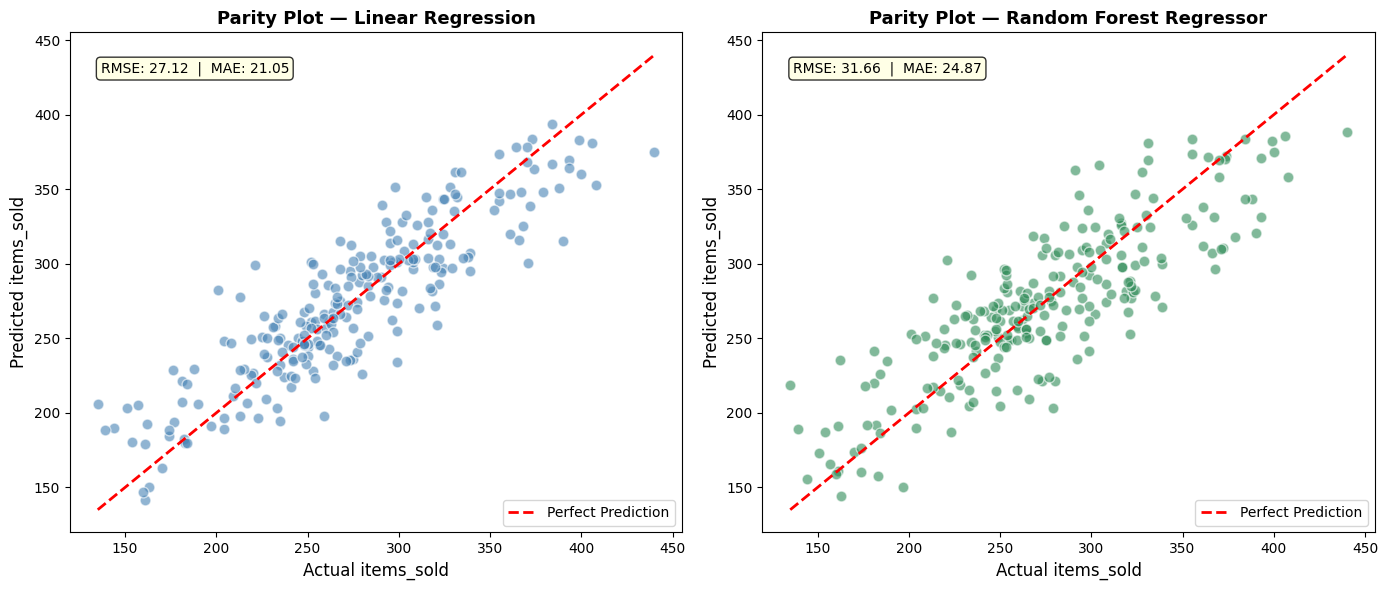

Parity plots saved as 'parity_plots.png'

RANDOM FOREST — ALL FEATURE IMPORTANCES
                      Feature  Importance
             store_size_small    0.183954
                  is_festival    0.174477
          location_type_urban    0.140498
                  day_of_week    0.090612
                   is_weekend    0.063547
                     store_id    0.062056
            store_size_medium    0.058178
          competition_density    0.053486
                        month    0.040473
     location_type_semi-urban    0.038886
promotion_type_loyalty_points    0.031470
                         year    0.017783
promotion_type_category_offer    0.016839
     promotion_type_free_gift    0.011558
 promotion_type_flat_discount    0.010469
                 is_month_end    0.005713

TOP 5 MOST INFLUENTIAL FEATURES
  #1  store_size_small                     0.1840  (18.40%)
  #2  is_festival                          0.1745  (17.45%)
  #3  location_type_urban                  0.1405  

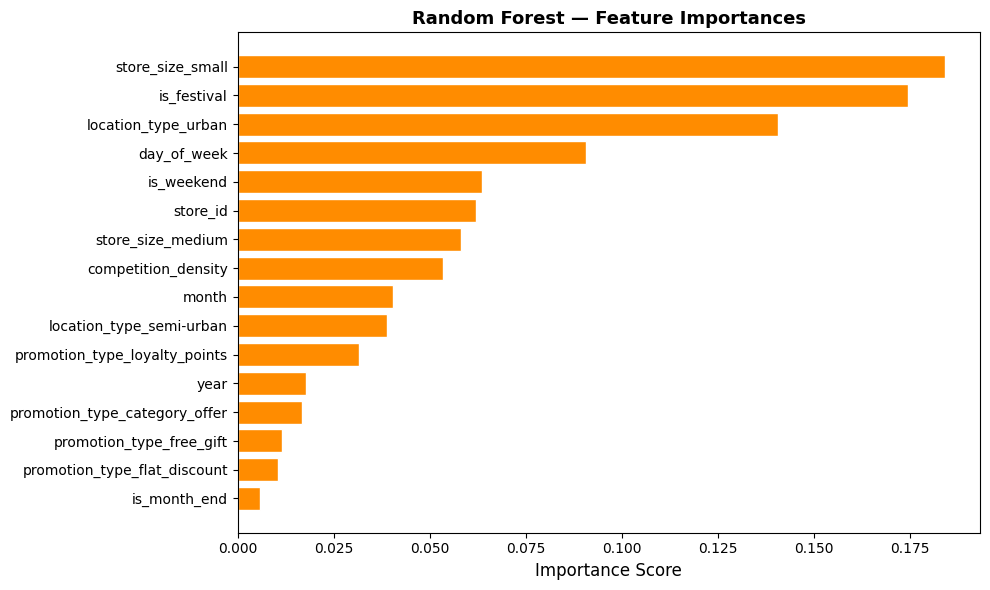

Feature importance chart saved as 'feature_importances.png'


In [9]:
# ============================================================
# TASK 4: Model Training and Evaluation
# ============================================================

# Step 1: Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ------------------------------------------------------------
# Step 2: Rebuild dataset from Task 1 + 2 + 3
# ------------------------------------------------------------
df = pd.read_csv('q3_retail_promotions.csv')
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['year']         = df['transaction_date'].dt.year
df['month']        = df['transaction_date'].dt.month
df['day_of_week']  = df['transaction_date'].dt.dayofweek
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)
df = df.sort_values('transaction_date').reset_index(drop=True)

split_index      = int(len(df) * 0.80)
train_df         = df.iloc[:split_index].copy()
test_df          = df.iloc[split_index:].copy()

categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols   = ['store_id', 'is_weekend', 'is_festival',
                    'competition_density', 'year', 'month',
                    'day_of_week', 'is_month_end']
target_col = 'items_sold'

X_train = train_df[categorical_cols + numerical_cols]
y_train = train_df[target_col]
X_test  = test_df[categorical_cols + numerical_cols]
y_test  = test_df[target_col]

# ------------------------------------------------------------
# Step 3: Build a reusable preprocessor function
# ------------------------------------------------------------
def make_preprocessor():
    return ColumnTransformer(transformers=[
        ('ohe',    OneHotEncoder(drop='first',
                                 sparse_output=False,
                                 handle_unknown='ignore'), categorical_cols),
        ('scaler', StandardScaler(), numerical_cols)
    ], remainder='drop')

# ============================================================
# TASK 4A: Train Model 1 — Linear Regression inside Pipeline
# ============================================================
lr_pipeline = Pipeline(steps=[
    ('preprocessor', make_preprocessor()),
    ('model',        LinearRegression())
])
lr_pipeline.fit(X_train, y_train)
print("Linear Regression trained successfully!")

# ============================================================
# TASK 4A: Train Model 2 — Random Forest inside Pipeline
# ============================================================
rf_pipeline = Pipeline(steps=[
    ('preprocessor', make_preprocessor()),
    ('model',        RandomForestRegressor(n_estimators=100, random_state=42))
])
rf_pipeline.fit(X_train, y_train)
print("Random Forest trained successfully!")

# ============================================================
# TASK 4B: Evaluate both models — RMSE and MAE on test set
# ============================================================
lr_preds = lr_pipeline.predict(X_test)
rf_preds = rf_pipeline.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mae  = mean_absolute_error(y_test, lr_preds)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae  = mean_absolute_error(y_test, rf_preds)

print()
print("="*55)
print("MODEL EVALUATION ON TEST SET")
print("="*55)
print(f"{'Metric':<10} {'Linear Regression':>20} {'Random Forest':>20}")
print("-"*55)
print(f"{'RMSE':<10} {lr_rmse:>20.2f} {rf_rmse:>20.2f}")
print(f"{'MAE':<10} {lr_mae:>20.2f} {rf_mae:>20.2f}")
print("="*55)

# ============================================================
# TASK 4C: Parity Plots — Predicted vs Actual
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, preds, title, color, rmse, mae in zip(
    axes,
    [lr_preds, rf_preds],
    ['Linear Regression', 'Random Forest Regressor'],
    ['steelblue', 'seagreen'],
    [lr_rmse, rf_rmse],
    [lr_mae, rf_mae]
):
    ax.scatter(y_test, preds, alpha=0.6, color=color, edgecolors='white', s=60)

    # Diagonal reference line (perfect prediction)
    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            'r--', linewidth=2, label='Perfect Prediction')

    ax.set_xlabel('Actual items_sold', fontsize=12)
    ax.set_ylabel('Predicted items_sold', fontsize=12)
    ax.set_title(f'Parity Plot — {title}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.text(0.05, 0.92, f'RMSE: {rmse:.2f}  |  MAE: {mae:.2f}',
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('parity_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Parity plots saved as 'parity_plots.png'")

# ============================================================
# TASK 4D: Feature Importances from Random Forest
# ============================================================

# Get OHE feature names
ohe_feature_names = (
    rf_pipeline
    .named_steps['preprocessor']
    .named_transformers_['ohe']
    .get_feature_names_out(categorical_cols)
    .tolist()
)
all_feature_names = ohe_feature_names + numerical_cols

# Extract importances
importances = rf_pipeline.named_steps['model'].feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature'   : all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print()
print("="*55)
print("RANDOM FOREST — ALL FEATURE IMPORTANCES")
print("="*55)
print(feat_imp_df.to_string(index=False))

print()
print("="*55)
print("TOP 5 MOST INFLUENTIAL FEATURES")
print("="*55)
top5 = feat_imp_df.head(5)
for rank, row in top5.iterrows():
    print(f"  #{rank+1}  {row['Feature']:<35}  {row['Importance']:.4f}  ({row['Importance']*100:.2f}%)")

# Plot feature importances (horizontal bar chart)
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'][::-1],
         feat_imp_df['Importance'][::-1],
         color='darkorange', edgecolor='white')
plt.xlabel('Importance Score', fontsize=12)
plt.title('Random Forest — Feature Importances', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance chart saved as 'feature_importances.png'")